In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PATH_TO_CSV_FILE = "../data/raw/Titanic-Dataset.csv"

Let's start by importing the .csv dataset to get a quick overview of the available data and its structure.

In [77]:
df = pd.read_csv(filepath_or_buffer=PATH_TO_CSV_FILE)

print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


As we can see, the dataset consists of **891 rows and 12 columns**. Before diving into specific features, let's establish a baseline by calculating the overall probability of survival for all passengers on board.

In [78]:
survived = df[
    df["Survived"] == 1
]

died = df[
    df["Survived"] == 0
]

pct_survived = (len(survived) / len(df)) * 100
pct_died = (len(died) / len(df)) * 100

print(f"Survived: {len(survived)} / {len(df)} = {pct_survived:.2f}%")
print(f"Died: {len(died)} / {len(df)} = {pct_died:.2f}%")

Survived: 342 / 891 = 38.38%
Died: 549 / 891 = 61.62%


Next, we need to find out which features strongly influenced a passenger's chances of surviving. The most logical starting points for this analysis are **`Pclass`**, **`Sex`**, **`Age`**, **`Embarked`**, and **`Fare`**.

--- Survival Stats by Pclass ---
        Total  Survived  Survival Rate
Pclass                                
1         216       136       0.629630
2         184        87       0.472826
3         491       119       0.242363


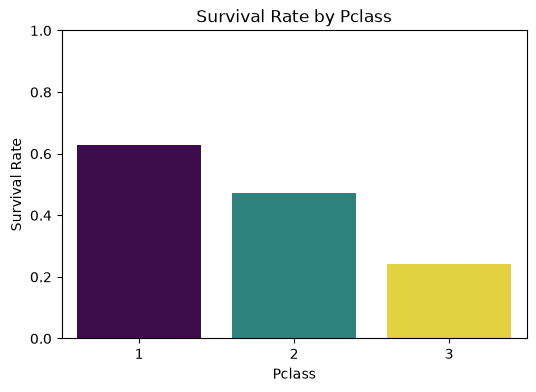

In [79]:
print("--- Survival Stats by Pclass ---")
pclass_stats = df.groupby('Pclass')['Survived'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Total', 'sum': 'Survived', 'mean': 'Survival Rate'}
)
print(pclass_stats)

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Pclass', y='Survived', errorbar=None, palette='viridis', hue='Pclass', legend=False)
plt.title('Survival Rate by Pclass')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.savefig(fname="figures/survival_by_class.png")
plt.show()

The odds of staying alive drop significantly as the ticket class decreases. Only **24% of third-class passengers survived**, compared to a solid **63% in first class**. This clearly shows that **socioeconomic status had a major impact** on survival chances. Now, let's examine how the actual ticket price (`Fare`) affects these probabilities.

--- Survival Stats by Fare Bins ---
                 Total  Survival Rate
Fare_Bin                             
(-0.001, 7.91]     223       0.197309
(7.91, 14.454]     224       0.303571
(14.454, 31.0]     222       0.454955
(31.0, 512.329]    222       0.581081


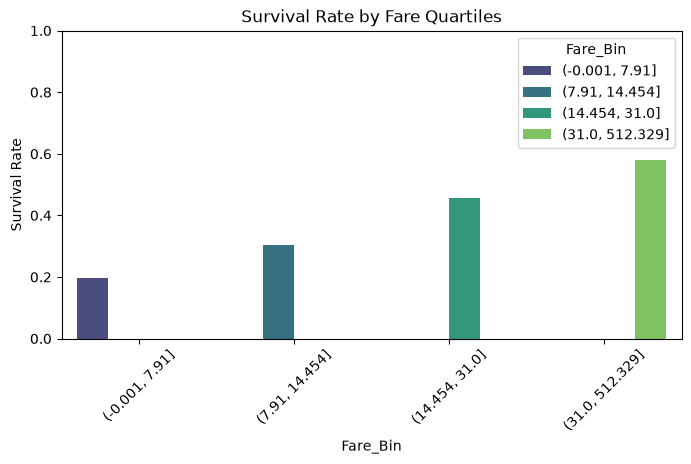

In [80]:
# split Fare into 4 equal-sized bins
df['Fare_Bin'] = pd.qcut(df['Fare'], 4)

print("--- Survival Stats by Fare Bins ---")
fare_stats = df.groupby('Fare_Bin')['Survived'].agg(['count', 'mean']).rename(
    columns={'count': 'Total', 'mean': 'Survival Rate'}
)
print(fare_stats)

plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Fare_Bin', y='Survived', errorbar=None, palette='viridis', hue="Fare_Bin")
plt.title('Survival Rate by Fare Quartiles')
plt.ylabel('Survival Rate')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.savefig(fname="figures/survival_by_fare.png")
plt.show()

As expected, the `Fare` distribution perfectly mirrors the `Pclass` analysis. The likelihood of survival **strictly increases along with the ticket price**. In fact, passengers in the **top 25% of the fare brackets had survival odds nearly three times higher** than those in the bottom 25%.

--- Survival Stats by Sex ---
        Total  Survived  Survival Rate
Sex                                   
female    314       233       0.742038
male      577       109       0.188908


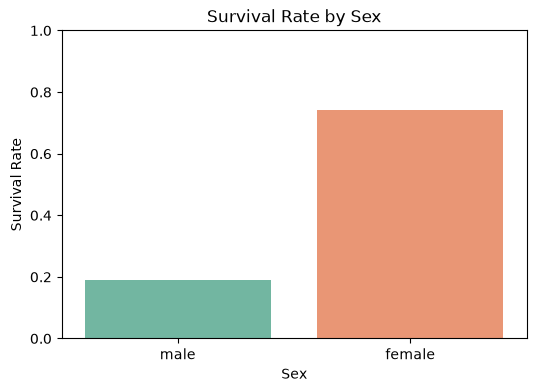

In [81]:
print("--- Survival Stats by Sex ---")
sex_stats = df.groupby('Sex')['Survived'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Total', 'sum': 'Survived', 'mean': 'Survival Rate'}
)
print(sex_stats)

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Sex', y='Survived', errorbar=None, palette='Set2', hue='Sex', legend=False)
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.savefig(fname="figures/survival_by_sex.png")
plt.show()

This plot highlights one of the most crucial pieces of information: **females had a survival probability four times higher than males**. This aligns perfectly with the historical **"women and children first"** protocol used during the evacuation.

--- Age Descriptive Stats by Survival ---
          count       mean        std   min   25%   50%   75%   max
Survived                                                           
0         424.0  30.626179  14.172110  1.00  21.0  28.0  39.0  74.0
1         290.0  28.343690  14.950952  0.42  19.0  28.0  36.0  80.0


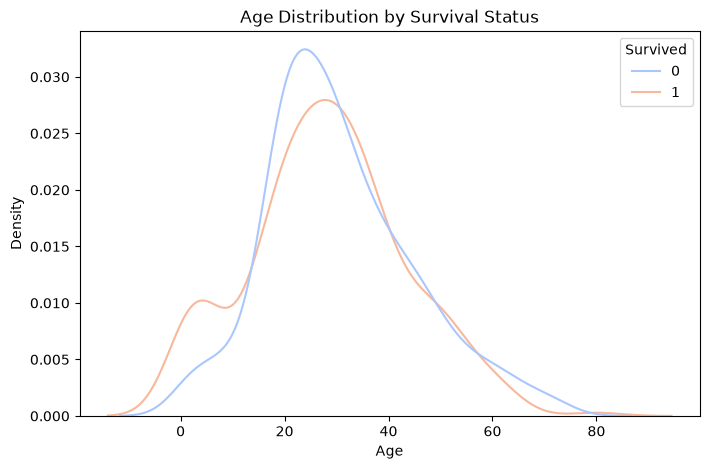

In [82]:
print("--- Age Descriptive Stats by Survival ---")
age_stats = df.groupby('Survived')['Age'].describe()
print(age_stats)

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Age', hue='Survived', common_norm=False, palette='coolwarm')
plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.savefig(fname="figures/survival_by_age.png")
plt.show()

At first glance, it might seem like age does not tell us much, since the average ages for both groups are quite similar. However, if we look closely at the spike on the left side of the plot, it is clear that **the vast majority of young children survived**. Let's prove this observation with hard numbers rather than just a visual.

In [83]:
children_only = df[df['Age'] <= 10]
survived = len(children_only[children_only['Survived'] == 1])
died = len(children_only) - survived

survival_rate = (survived / len(children_only)) * 100
death_rate = (died / len(children_only)) * 100

print(f"Survival rate across children: {survival_rate:.2f}%")
print(f"Death rate across children: {death_rate:.2f}%")

Survival rate across children: 59.38%
Death rate across children: 40.62%


--- Survival Stats by Embarked ---
          Total  Survived  Survival Rate
Embarked                                
C           168        93       0.553571
Q            77        30       0.389610
S           644       217       0.336957


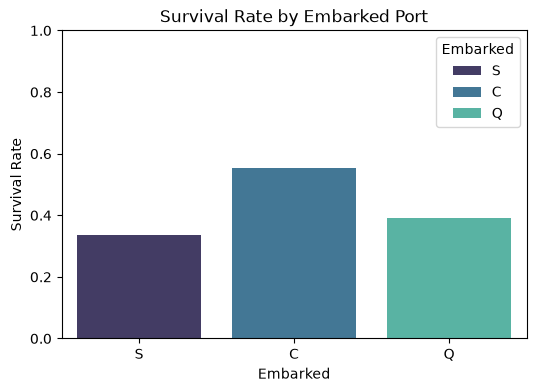

In [84]:
print("--- Survival Stats by Embarked ---")
embarked_stats = df.groupby('Embarked')['Survived'].agg(['count', 'sum', 'mean']).rename(
    columns={'count': 'Total', 'sum': 'Survived', 'mean': 'Survival Rate'}
)
print(embarked_stats)

plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Embarked', y='Survived', errorbar=None, palette='mako', hue="Embarked")
plt.title('Survival Rate by Embarked Port')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.savefig(fname="figures/survival_by_embarked_port.png")
plt.show()

For context, the `Embarked` ports are:

- **S** = Southampton (England)
- **C** = Cherbourg (France)
- **Q** = Queenstown (Ireland)

Passengers who boarded in France seemed more likely to survive. Let's investigate if this is actually tied to the port itself, or simply a result of their class and wealth.

In [85]:
embarked_in_france = df[
    df['Embarked'] == "C"
]

first_class = len(embarked_in_france[
    embarked_in_france["Pclass"] == 1
])

percentage = (first_class / len(embarked_in_france)) * 100

print(f"Embarked in France & 1st Class: {first_class} / {len(embarked_in_france)} ({percentage:.2f}%)")

Embarked in France & 1st Class: 85 / 168 (50.60%)


The results reveal that **50% of the passengers who embarked in France held first-class tickets**, while the rest were distributed between second and third class. Since we already established that class heavily dictates the odds of surviving, this explains why the Cherbourg passengers had better outcomes. We can confidently conclude that **the 17% higher survival rate for French passengers is driven by their wealth and first-class status**, not the actual origin of their embarkation.

The final category I want to evaluate in this section is **family size**. We can easily calculate this by combining the `Parch` (parents/children) and `SibSp` (siblings/spouses) columns, and then adding 1 to account for the passenger themselves. This means a **solo traveler will have a family size score of 1**.

--- Survival Stats by Family Size ---
            Total  Survival Rate
FamilySize                      
1             537       0.303538
2             161       0.552795
3             102       0.578431
4              29       0.724138
5              15       0.200000
6              22       0.136364
7              12       0.333333
8               6       0.000000
11              7       0.000000


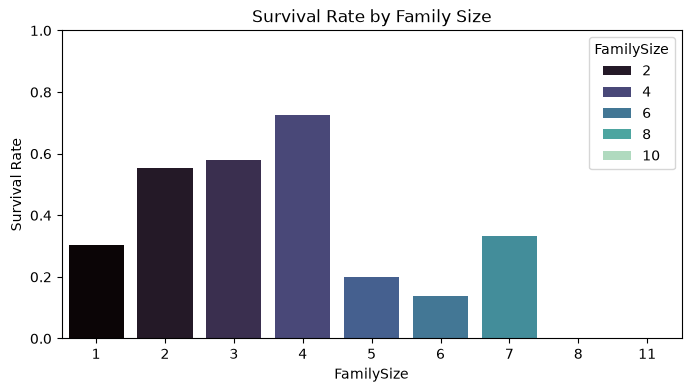

In [86]:
# create FamilySize feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

print("--- Survival Stats by Family Size ---")
family_stats = df.groupby('FamilySize')['Survived'].agg(['count', 'mean']).rename(
    columns={'count': 'Total', 'mean': 'Survival Rate'}
)
print(family_stats)

plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='FamilySize', y='Survived', errorbar=None, palette='mako', hue="FamilySize")
plt.title('Survival Rate by Family Size')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.savefig(fname="figures/survival_by_family_size.png")
plt.show()

The results here are quite interesting. **Passengers traveling with a small family unit had noticeably better survival chances** than those who were either completely alone or traveling with a very large family.

Taking everything into account, **gender provides the strongest indicator** for surviving the disaster. Being in **first class also significantly improved survival odds**, which is perfectly mirrored by the `Fare` distribution. Furthermore, the `Age` distribution clearly shows that **children had a much higher likelihood** of making it out alive. Finally, the better survival probability for passengers who boarded in **Cherbourg** was simply driven by their **wealth and first-class status**, rather than the port itself.

Moving on, let's address the **missing values** in our dataset. My initial thought was to completely drop the `Cabin` column because nearly 80% of its data is missing. To get a better perspective, let's print out the exact percentage of missing values for every single column.

In [87]:
for column in df.columns:
    print(f"{column}:\t{df[column].isna().mean()}")

PassengerId:	0.0
Survived:	0.0
Pclass:	0.0
Name:	0.0
Sex:	0.0
Age:	0.19865319865319866
SibSp:	0.0
Parch:	0.0
Ticket:	0.0
Fare:	0.0
Cabin:	0.7710437710437711
Embarked:	0.002244668911335578
Fare_Bin:	0.0
FamilySize:	0.0


My assumption about the `Cabin` column was correct: **roughly 77% of the data is missing**. However, I suspect that these cabin numbers are missing primarily because cabins were mostly assigned to first-class passengers. Let's test this theory.

In [88]:
print((df[df['Cabin'].notna()]['Pclass'] == 1).sum())

176


The theory holds up — out of the **204 passengers with a recorded cabin, 176 of them held first-class tickets**. Since we already know that passenger class heavily impacts the likelihood of surviving, let's see how many people with a known cabin actually made it out alive.

In [89]:
have_cabin = df[
    df["Cabin"].notna()
]

survived = have_cabin[
    have_cabin["Survived"] == 1
]

died = have_cabin[
    have_cabin["Survived"] == 0
]

survived_pct = (len(survived) / len(have_cabin)) * 100
died_pct = (len(died) / len(have_cabin)) * 100

survived_first_class = survived[
    survived["Pclass"] == 1
]

first_class_survived_pct = (len(survived_first_class) / len(survived)) * 100

print(f"Have cabin & Survived: {len(survived)} / {len(have_cabin)} ({survived_pct:.2f}%)")
print(f"Have cabin & Died: {len(died)} / {len(have_cabin)} ({died_pct:.2f}%)")
print(f"Have cabin & Survived & 1st class: {len(survived_first_class)} / {len(survived)} ({first_class_survived_pct:.2f}%)")

Have cabin & Survived: 136 / 204 (66.67%)
Have cabin & Died: 68 / 204 (33.33%)
Have cabin & Survived & 1st class: 117 / 136 (86.03%)


As we can see, **simply having a recorded cabin has a huge impact on survival chances, pushing it up to 66.7%**. Furthermore, a passenger who was in **first class and had a cabin saw their probability of survival jump to 86%** — which is **23 percentage points higher** than the general first-class average. Next, let's examine the survival odds for passengers with a missing cabin, specifically focusing on first-class passengers without a recorded cabin number.

In [90]:
no_cabin = df[
    df["Cabin"].isna()
]

survived = no_cabin[
    no_cabin["Survived"] == 1
]

died = no_cabin[
    no_cabin["Survived"] == 0
]

first_class_no_cabin = no_cabin[
    no_cabin["Pclass"] == 1
]

first_class_no_cabin_survived = first_class_no_cabin[
    first_class_no_cabin["Survived"] == 1
]

first_class_no_cabin_died = first_class_no_cabin[
    first_class_no_cabin["Survived"] == 0
]

pct_no_cabin_survived = (len(survived) / len(no_cabin)) * 100
pct_no_cabin_died = (len(died) / len(no_cabin)) * 100
pct_first_class_survived = (len(first_class_no_cabin_survived) / len(survived)) * 100
pct_first_class_died = (len(first_class_no_cabin_died) / len(died)) * 100
survival_rate_for_first_class_no_cabin = (len(first_class_no_cabin_survived) / len(first_class_no_cabin)) * 100

print(
    f"No cabin & Survived: {len(survived)} / {len(no_cabin)}"
    f" ({pct_no_cabin_survived:.2f}%)"
)
print(
    f"No cabin & Died: {len(died)} / {len(no_cabin)} ({pct_no_cabin_died:.2f}%)"
)
print(
    "No cabin & Survived & 1st class:"
    f" {len(first_class_no_cabin_survived)} / {len(survived)}"
    f" ({pct_first_class_survived:.2f}%)"
)
print(
    f"No cabin & Died & 1st class: {len(first_class_no_cabin_died)} /"
    f" {len(died)} ({pct_first_class_died:.2f}%)"
)
print(
    "No cabin & 1st class & Survived:"
    f" {len(first_class_no_cabin_survived)} / {len(first_class_no_cabin)}"
    f" ({survival_rate_for_first_class_no_cabin:.2f}%)"
)

No cabin & Survived: 206 / 687 (29.99%)
No cabin & Died: 481 / 687 (70.01%)
No cabin & Survived & 1st class: 19 / 206 (9.22%)
No cabin & Died & 1st class: 21 / 481 (4.37%)
No cabin & 1st class & Survived: 19 / 40 (47.50%)


The contrast here is significant. **People without a cabin had a survival rate that was two times lower** than those with one. While almost every first-class passenger had a recorded cabin, the few who didn't faced a huge drop in their survival chances: falling from **86% to 47.5%** (though this is still noticeably higher than the ship's overall **30% average**). This proves once again that **class had an enormous effect on survival**, but the mere possession of a cabin indicator further boosted those odds.

Now let's figure out why the `Age` column has missing values. My first hypothesis is that these missing ages mostly belong to babies and newborns. We could try checking this by filtering for `Parch == 2`, assuming babies travel with both parents. However, the flaw in this logic is that a parent traveling with two children would also have a `Parch` score of 2.

In [91]:
# count missing ages for families with Parch == 2
large_family_missing_age = df[df['Age'].isna() & (df['Parch'] == 2)]
babies_or_parents  = len(large_family_missing_age)

print(f"Passengers with missing Age and Parch > 2: {babies_or_parents}")

total_missing_age = df['Age'].isna().sum()
percentage = (babies_or_parents / total_missing_age) * 100


print(f"Missing Age and are Parents or Children: {babies_or_parents} / {total_missing_age} ({percentage:.2f}%)")

Passengers with missing Age and Parch > 2: 12
Missing Age and are Parents or Children: 12 / 177 (6.78%)


This filter successfully **disproved the hypothesis**. It clearly shows that **the missing ages do not primarily belong to children traveling with their parents**.

Since that didn't work, let's look at the opposite scenario. Let's check how many passengers with a missing age were traveling completely alone and ended up dying. This could imply that there were no surviving family members left to identify them or provide their age for the records.

In [92]:
# Filter for missing Age, no siblings/spouses, no parents/children, and Survived == 0
missing_age_alone_died = df[
    df['Age'].isna() & 
    (df['SibSp'] == 0) &        # sibsp = siblings, spouses
    (df['Parch'] == 0) &        # parch = parents, children
    (df['Survived'] == 0)
]

# Total count
count_alone_died = len(missing_age_alone_died)
total_missing_age = df['Age'].isna().sum()
percentage = (count_alone_died / total_missing_age) * 100

print(f"Missing Age & Died Alone: {count_alone_died} / {total_missing_age} ({percentage:.2f}%)")

Missing Age & Died Alone: 100 / 177 (56.50%)


This is a great finding: **56.5% of the people with a missing age were solo travelers who did not survive** the disaster.

I have one more idea. Given the strict **"women and children first"** evacuation policy, it is highly likely that **the missing ages predominantly belong to adult men**.

In [93]:
missing_age_men = df[
    df['Age'].isna() & 
    (df['Sex'] == "male")
]

count_men_with_missing_age = len(missing_age_men)
total_missing_age = df['Age'].isna().sum()
count_women_with_missing_age = total_missing_age - count_men_with_missing_age

pct_men = (count_men_with_missing_age / total_missing_age) * 100
pct_women = (count_women_with_missing_age / total_missing_age) * 100

print(f"Missing Age & Man: {count_men_with_missing_age} / {total_missing_age} ({pct_men:.2f}%)")
print(f"Missing Age & Woman: {count_women_with_missing_age} / {total_missing_age} ({pct_women:.2f}%)")

Missing Age & Man: 124 / 177 (70.06%)
Missing Age & Woman: 53 / 177 (29.94%)


This is another solid spot. **A passenger with a missing age is 70% likely to be male**, and we already know **56.5% of the missing ages belong to people who traveled alone and died**. Let's combine these conditions to form a sharper conclusion.

In [94]:
man_missing_age_alone_died = df[
    df['Age'].isna() & 
    (df['SibSp'] == 0) &        # sibsp = siblings, spouses
    (df['Parch'] == 0) &        # parch = parents, children
    (df['Survived'] == 0) &
    (df["Sex"] == "male")
]

pct = (len(man_missing_age_alone_died) / len(missing_age_alone_died)) * 100

print(f"The pct of man among passengers with missing age, who travelled alone and died: {pct}%")

The pct of man among passengers with missing age, who travelled alone and died: 94.0%


Now the full picture comes together. Not only is a solo passenger with a missing age **70% likely to be a man** and **56% likely to die**, but if we specifically look at **men traveling alone with no recorded age, an overwhelming 94% of them did not survive**.

To deal with the missing age data, we can try to recover it by looking at the passenger's **title**. For instance, **`"Master"`** was historically used for boys under 12–14, **`"Mr."`** designates an adult male, **`"Mrs."`** is a married woman, and **`"Miss"`** refers to an unmarried female (which covers both adults and young girls).

In [95]:
# extract and standardize titles
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# share of each title among ALL people with missing age (sum = 100%)
missing_distribution = df[df['Age'].isna()]['Title'].value_counts(normalize=True) * 100

print("Title distribution among missing data:")
print(missing_distribution)

Title distribution among missing data:
Title
Mr        67.231638
Miss      20.338983
Mrs        9.604520
Master     2.259887
Dr         0.564972
Name: proportion, dtype: float64


This distribution completely validates my theory. **The vast majority of passengers with missing ages are adult men (`"Mr."`)**. Mothers (`"Mrs."`) and male children (`"Master"`) rarely have missing ages because they were much more likely to survive and had family members present to report their details. Moving forward, my strategy will be to **fill in the missing ages using the average age of passengers who share the exact same title and ticket class**.

To sum up the missing data handling: even though roughly **77% of the `Cabin` records are missing**, we should **keep this column as a binary feature**. The mere fact of having a recorded cabin greatly improves survival chances, jumping from **63% to 86%** for first-class passengers. For the missing values in the `Age` column, a solid approach is to **fill them using the average age of passengers grouped by both ticket class and their title**. Lastly, since there are only **two missing `Embarked` values**, we can simply fill them with the most frequent port (the **mode**).

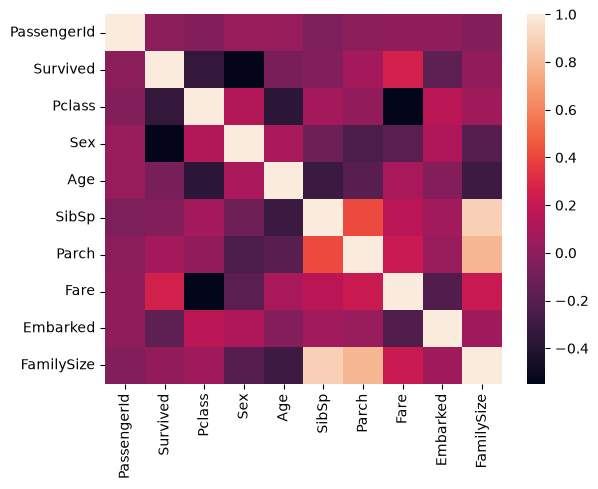

In [96]:
df["Sex"] = df["Sex"].map({"male": 1, "female": 0})
df["Embarked"] = df["Embarked"].map({"C": 1, "Q": 2, "S": 3})

sns.heatmap(df.corr(numeric_only=True))

plt.savefig("figures/correlation_heatmap.png", bbox_inches="tight", dpi=300)
plt.show()

## Conclusions and Dependencies from Heatmap

- **`Fare` goes up, `Pclass` goes down** — higher ticket prices correspond to lower (better) passenger class numbers.
- **Women are more likely to survive than men** — gender remains one of the strongest predictors of survival.
- **The lower the `Pclass`, the bigger the chances to survive** — first-class passengers had significantly higher survival odds.
- **The lower the `Pclass`, the bigger the `Age`** — older passengers tended to hold higher-class tickets.
- **The lower the `Age`, the bigger the `FamilySize` and `SibSp`** — which is pretty obvious, since children typically travel with their parents and siblings.